In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [5]:
#TODO: Add the path to your dataset
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
# Check for missing value
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [10]:
duplicates = sum(df.duplicated())
print(duplicates)

0


========================Before the removal of outliers===================================================


Text(0.5, 1.0, "['DiabetesPedigreeFunction']")

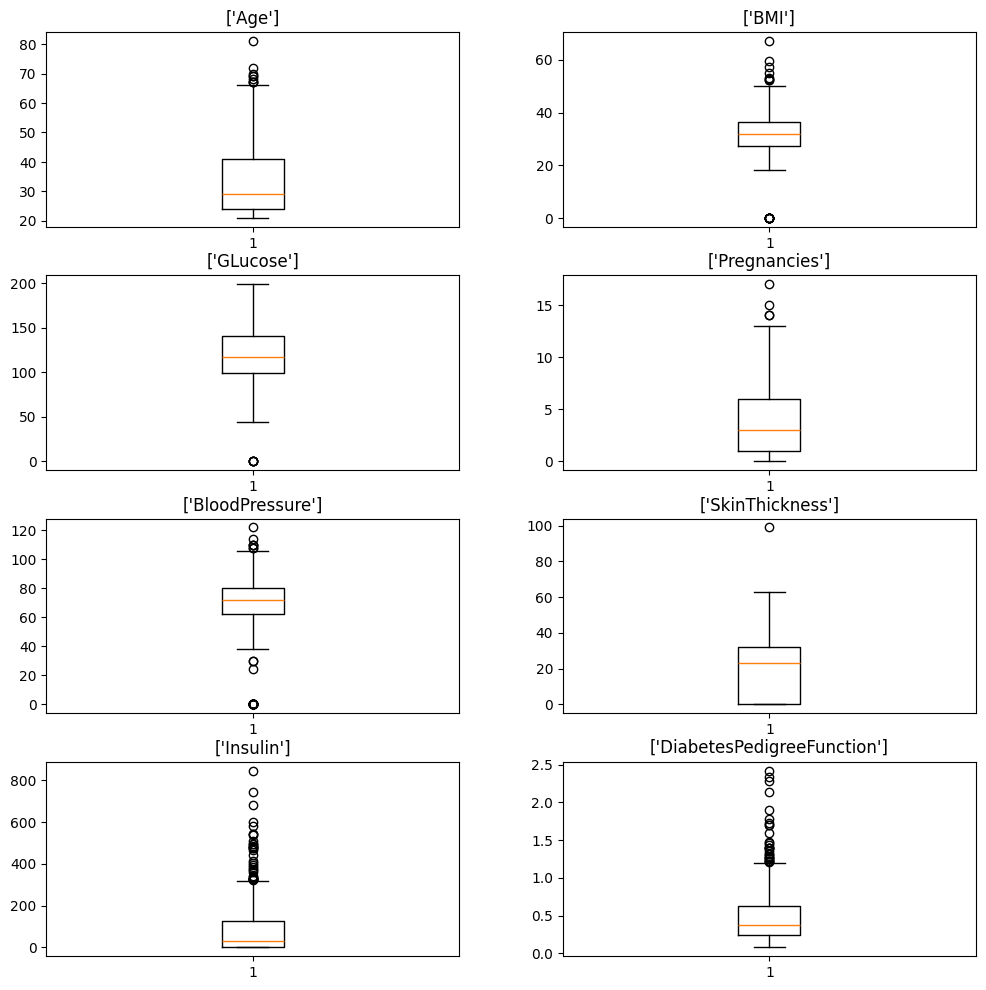

In [11]:
print("========================Before the removal of outliers===================================================")
fig, ax = plt.subplots(4,2, figsize=(12,12))
fig.subplots_adjust(wspace=0.25, hspace=0.25)

ax[0][0].boxplot(df['Age'])
ax[0][0].set_title(['Age'])

ax[0][1].boxplot(df['BMI'])
ax[0][1].set_title(['BMI'])


ax[1][0].boxplot(df['Glucose'])
ax[1][0].set_title(['GLucose'])

ax[1][1].boxplot(df['Pregnancies'])
ax[1][1].set_title(['Pregnancies'])

ax[2][0].boxplot(df['BloodPressure'])
ax[2][0].set_title(['BloodPressure'])

ax[2][1].boxplot(df['SkinThickness'])
ax[2][1].set_title(['SkinThickness'])

ax[3][0].boxplot(df['Insulin'])
ax[3][0].set_title(['Insulin'])

ax[3][1].boxplot(df['DiabetesPedigreeFunction'])
ax[3][1].set_title(['DiabetesPedigreeFunction'])

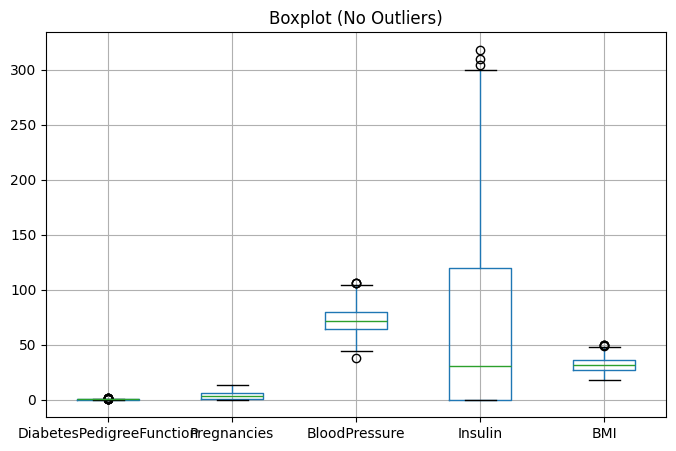

In [12]:
# Outlier removal

columns = ["DiabetesPedigreeFunction", "Pregnancies", "BloodPressure", "Insulin", "BMI"]

Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# FIX: apply condition across all columns
df_no_outliers = df[((df[columns] >= lower_bound) & (df[columns] <= upper_bound)).all(axis=1)]

# Plot
plt.figure(figsize=(8, 5))
df_no_outliers[columns].boxplot()
plt.title('Boxplot (No Outliers)')
plt.show()

In [13]:
import numpy as np
from sklearn.impute import SimpleImputer

# Step 1: Make a proper copy (VERY IMPORTANT)
df_no_outliers = df_no_outliers.copy()

# Step 2: Replace 0 with NaN
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_no_outliers.loc[:, cols_with_zero] = df_no_outliers[cols_with_zero].replace(0, np.nan)

# Step 3: Impute missing values
imputer = SimpleImputer(strategy='median')
df_no_outliers.loc[:, cols_with_zero] = imputer.fit_transform(df_no_outliers[cols_with_zero])



/tmp/ipykernel_3903/3288841400.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[148.  85. 183.  89. 116.  78. 110. 168. 166. 118. 107. 115. 126.  99.
 196. 119. 143. 125. 147.  97. 145. 117. 109. 158.  88.  92. 122. 103.
 138. 102.  90. 180. 133. 106. 159. 146.  71. 103. 103. 101.  88. 176.
  73. 187. 100. 105. 133.  44. 141. 114.  99. 109. 109.  95. 146. 100.
 139. 126. 129.  79.  nan  62.  95. 112. 113.  83. 101. 110. 106. 100.
 107.  80. 123.  81. 134. 142. 144.  92.  71.  93. 122. 151. 125.  81.
  85. 126. 144.  83.  95. 171.  89.  76. 160. 146. 124.  78.  97.  99.
 111. 107. 132. 113. 120. 118. 117. 105. 173. 122. 170.  84.  96. 125.
 100.  93. 129. 128. 106. 108. 108. 154.  57. 147.  90. 136. 114. 156.
 188. 152.  99. 109.  88. 151. 102. 114. 100. 131. 104. 148. 120. 110.
 111. 102. 134.  79.  75. 179.  85. 143. 130.  87. 119.  nan  73. 141.
 194. 109. 139. 111. 123. 159.  85. 158. 105. 107. 109. 148. 113

In [14]:
np.isnan(df_no_outliers).sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [15]:
scaler = StandardScaler()

In [16]:
# Step 1: Replace
df_no_outliers.loc[:, cols_with_zero] = df_no_outliers[cols_with_zero].replace(0, np.nan)

# Step 2: Impute
df_no_outliers.loc[:, cols_with_zero] = imputer.fit_transform(df_no_outliers[cols_with_zero])

# Step 3: Confirm no NaN
print(df_no_outliers.isna().sum())

# Step 4: Scale
X_scaled = scaler.fit_transform(df_no_outliers.drop("Outcome", axis=1))

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [17]:
from sklearn.model_selection import train_test_split

X = X_scaled
y = df_no_outliers["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7862595419847328
[[83  9]
 [19 20]]
              precision    recall  f1-score   support

           0       0.81      0.90      0.86        92
           1       0.69      0.51      0.59        39

    accuracy                           0.79       131
   macro avg       0.75      0.71      0.72       131
weighted avg       0.78      0.79      0.78       131



In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7633587786259542


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6641221374045801


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7251908396946565


In [23]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7709923664122137


In [24]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))

Logistic: 0.7862595419847328
KNN: 0.7633587786259542
Decision Tree: 0.6641221374045801
Random Forest: 0.7251908396946565
SVM: 0.7709923664122137


In [25]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        92
           1       0.55      0.44      0.49        39

    accuracy                           0.73       131
   macro avg       0.66      0.64      0.65       131
weighted avg       0.71      0.73      0.72       131



In [26]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic", "KNN", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [0.7704, 0.7704, 0.6173, 0.7704, 0.7602]
})

print(results)

           Model  Accuracy
0       Logistic    0.7704
1            KNN    0.7704
2  Decision Tree    0.6173
3  Random Forest    0.7704
4            SVM    0.7602


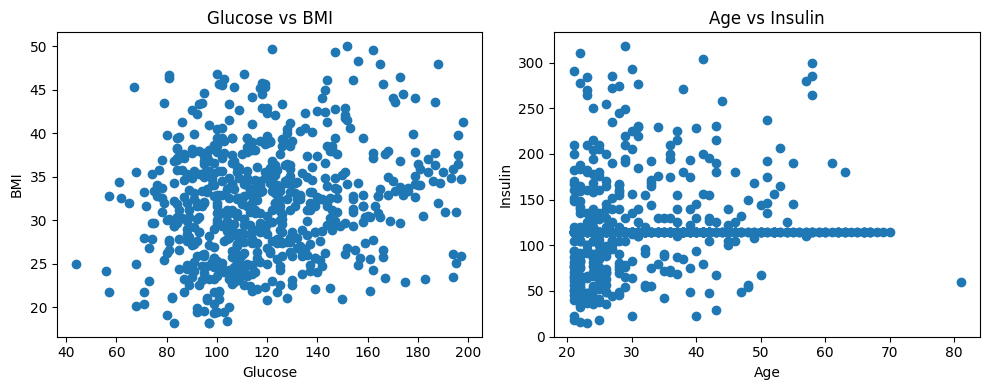

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Plot 1
plt.subplot(1,2,1)
plt.scatter(df_no_outliers["Glucose"], df_no_outliers["BMI"])
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")

# Plot 2
plt.subplot(1,2,2)
plt.scatter(df_no_outliers["Age"], df_no_outliers["Insulin"])
plt.title("Age vs Insulin")
plt.xlabel("Age")
plt.ylabel("Insulin")

plt.tight_layout()
plt.show()

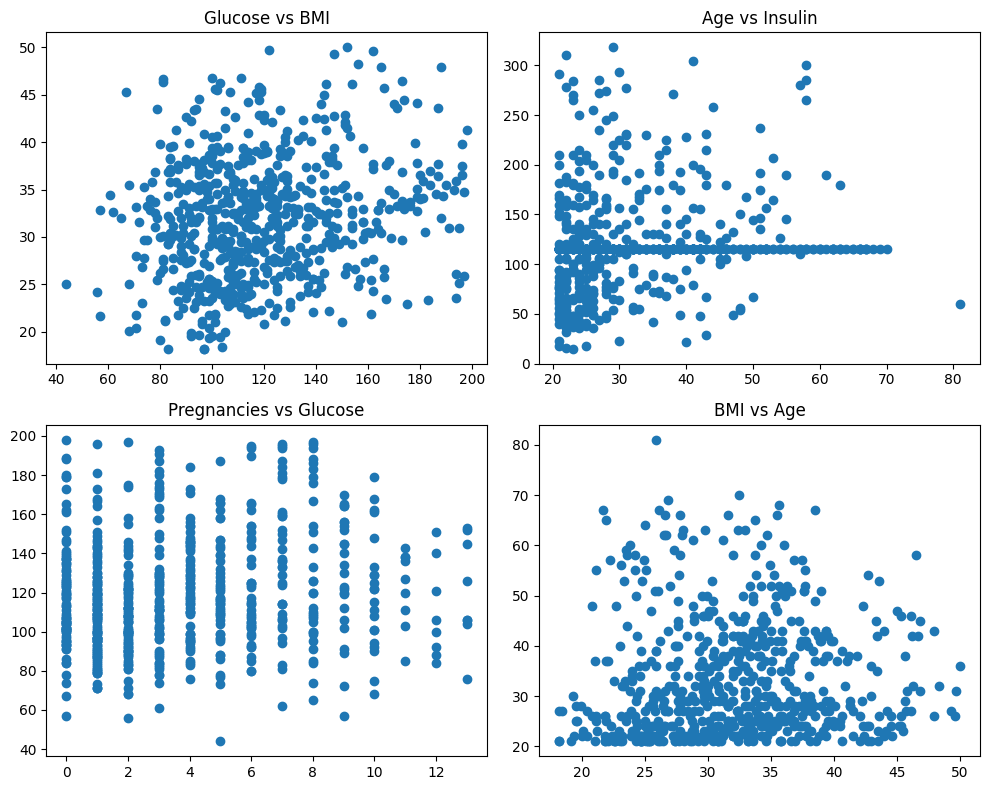

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes[0,0].scatter(df_no_outliers["Glucose"], df_no_outliers["BMI"])
axes[0,0].set_title("Glucose vs BMI")

axes[0,1].scatter(df_no_outliers["Age"], df_no_outliers["Insulin"])
axes[0,1].set_title("Age vs Insulin")

axes[1,0].scatter(df_no_outliers["Pregnancies"], df_no_outliers["Glucose"])
axes[1,0].set_title("Pregnancies vs Glucose")

axes[1,1].scatter(df_no_outliers["BMI"], df_no_outliers["Age"])
axes[1,1].set_title("BMI vs Age")

plt.tight_layout()
plt.show()

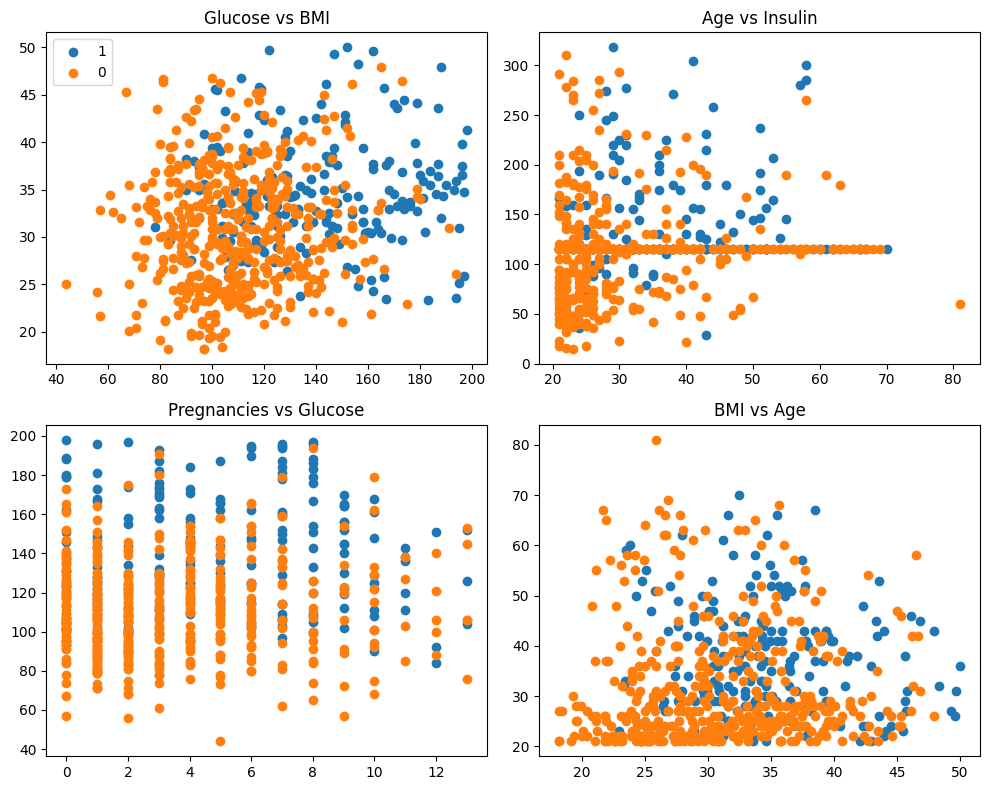

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(10,8))

# Plot 1
for label in df_no_outliers["Outcome"].unique():
    subset = df_no_outliers[df_no_outliers["Outcome"] == label]
    axes[0,0].scatter(subset["Glucose"], subset["BMI"], label=label)
axes[0,0].set_title("Glucose vs BMI")
axes[0,0].legend()

# Plot 2
for label in df_no_outliers["Outcome"].unique():
    subset = df_no_outliers[df_no_outliers["Outcome"] == label]
    axes[0,1].scatter(subset["Age"], subset["Insulin"], label=label)
axes[0,1].set_title("Age vs Insulin")

# Plot 3
for label in df_no_outliers["Outcome"].unique():
    subset = df_no_outliers[df_no_outliers["Outcome"] == label]
    axes[1,0].scatter(subset["Pregnancies"], subset["Glucose"], label=label)
axes[1,0].set_title("Pregnancies vs Glucose")

# Plot 4
for label in df_no_outliers["Outcome"].unique():
    subset = df_no_outliers[df_no_outliers["Outcome"] == label]
    axes[1,1].scatter(subset["BMI"], subset["Age"], label=label)
axes[1,1].set_title("BMI vs Age")

plt.tight_layout()
plt.show()

In [30]:
import joblib

In [31]:
joblib.dump(model, 'diabetes_model.pkl')

['diabetes_model.pkl']